In [ ]:
!pip install ultralytics albumentations opencv-python-headless roboflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 77.0 MB/s eta 0:00:00


In [ ]:
from roboflow import Roboflow

# 1. DOWNLOAD DATASET CNK
print("Mendownload Dataset CNK...")
rf = Roboflow(api_key="kQ4p3BC8diTVdmSClhGD")
project_cnk = rf.workspace("rivans-workspace").project("cnk_project_revise-3")
version_cnk = project_cnk.version(2)
dataset_cnk = version_cnk.download("yolov8")
path_cnk = dataset_cnk.location

# 2. DOWNLOAD DATASET BATIK
print("Mendownload Dataset Batik...")
project_batik = rf.workspace("rivans-workspace").project("batik-tkocp")
version_batik = project_batik.version(1)
dataset_batik = version_batik.download("yolov8")
path_batik = dataset_batik.location

print("✅ Download selesai!")

Mendownload Dataset CNK...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to CNK_Project_Revise-3-2 in yolov8:: 100%|██████████| 428/428 [00:00<00:00, 4925.13it/s]

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mendownload Dataset Batik...
loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to Batik-1 in yolov8:: 100%|██████████| 566/566 [00:00<00:00, 1756.86it/s]

✅ Download selesai!


In [ ]:
import os
import shutil
import yaml

# Buat folder penampungan akhir
super_path = "/content/Dataset_Super"
os.makedirs(super_path, exist_ok=True)

splits = ['train', 'valid', 'test']

for split in splits:
    os.makedirs(f"{super_path}/{split}/images", exist_ok=True)
    os.makedirs(f"{super_path}/{split}/labels", exist_ok=True)

    # ==========================================
    # 1. COPY CNK (Class 0 -> Tetap 0)
    # ==========================================
    cnk_split_img = f"{path_cnk}/{split}/images"
    cnk_split_lbl = f"{path_cnk}/{split}/labels"

    if os.path.exists(cnk_split_img):
        for file in os.listdir(cnk_split_img):
            shutil.copy(f"{cnk_split_img}/{file}", f"{super_path}/{split}/images/cnk_{file}")
        for file in os.listdir(cnk_split_lbl):
            shutil.copy(f"{cnk_split_lbl}/{file}", f"{super_path}/{split}/labels/cnk_{file}")

    # ==========================================
    # 2. COPY BATIK & UBAH LABEL (Class 0 -> Jadi 1)
    # ==========================================
    batik_split_img = f"{path_batik}/{split}/images"
    batik_split_lbl = f"{path_batik}/{split}/labels"

    if os.path.exists(batik_split_img):
        for file in os.listdir(batik_split_img):
            shutil.copy(f"{batik_split_img}/{file}", f"{super_path}/{split}/images/batik_{file}")

        # Buka setiap file teks Batik, ubah angka depan dari 0 menjadi 1
        for file in os.listdir(batik_split_lbl):
            with open(f"{batik_split_lbl}/{file}", 'r') as f:
                lines = f.readlines()

            with open(f"{super_path}/{split}/labels/batik_{file}", 'w') as f:
                for line in lines:
                    parts = line.strip().split()
                    if len(parts) > 0:
                        parts[0] = '1' # Paksa ubah ID Kelas menjadi 1 (Batik)
                        f.write(" ".join(parts) + "\n")

# ==========================================
# 3. BUAT FILE DATA.YAML BARU
# ==========================================
yaml_content = {
    'train': f"{super_path}/train/images",
    'val': f"{super_path}/valid/images",
    'test': f"{super_path}/test/images",
    'nc': 2,
    'names': ['cnk_uniform', 'batik']
}

with open(f"{super_path}/data.yaml", 'w') as f:
    yaml.dump(yaml_content, f, sort_keys=False)

print("✅ PENGGABUNGAN SELESAI! Dataset_Super dengan 2 Kelas siap digunakan.")

✅ PENGGABUNGAN SELESAI! Dataset_Super dengan 2 Kelas siap digunakan.


In [ ]:
# from roboflow import Roboflow
# from ultralytics import YOLO
# import os

# rf = Roboflow(api_key="kQ4p3BC8diTVdmSClhGD")
# project = rf.workspace("rivans-workspace").project("cnk_project_revise_3_2")
# version = project.version(1)
# dataset = version.download("yolov8")

# # Roboflow akan mendownload ke folder: /content/cnk-project-5/ (cek sidebar folder)
# dataset_path = dataset.location
# yaml_path = os.path.join(dataset_path, "data.yaml")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to CNK_Project_Revise_3_2-1 in yolov8:: 100%|██████████| 984/984 [00:00<00:00, 9223.73it/s]


In [ ]:
# # 2. Load Model Pre-trained
# model = YOLO('yolov8n.pt')

# # 3. Mulai Pelatihan
# model.train(
#     data=yaml_path,        # Menggunakan file yaml hasil download SDK
#     epochs=100,
#     imgsz=640,
#     batch=16,
#     device=0,              # Gunakan GPU T4

#     # --- AUGMENTASI TETAP DIGUNAKAN ---
#     degrees=15.0,
#     translate=0.1,
#     scale=0.5,
#     shear=2.0,             # Saya turunkan ke 2.0 agar tidak terlalu distorsi
#     perspective=0.0,       # Dimatikan sementara agar model lebih stabil
#     fliplr=0.5,
#     # hsv_h=0.01,
#     # hsv_s=0.7,
#     # hsv_v=0.4,
#     mosaic=1.0,
#     mixup=0.1,
#     #Jabarkan langkah langkahnya

#     # Tambahkan ini agar model berhenti jika tidak ada kemajuan (mencegah overfitting)
#     patience=20,
#     save=True
# )

Ultralytics 8.4.26 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/CNK_Project_Revise_3_2-1/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20

KeyboardInterrupt: 

In [ ]:
import os
import cv2
import albumentations as A
from tqdm import tqdm

# ==========================================
# 1. DEFINISIKAN PIPELINE AUGMENTASI
# ==========================================
# Aturan untuk CNK (Ketat: Tanpa ubah warna, hanya cerah & rotasi ringan)
transform_cnk = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.7),
    A.SafeRotate(limit=10, p=0.5), # Miring maksimal 10 derajat
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# Aturan untuk BATIK (Ekstrim: Acak warna, efek lipatan/shear, rotasi)
transform_batik = A.Compose([
    A.HueSaturationValue(hue_shift_limit=50, sat_shift_limit=50, val_shift_limit=20, p=0.9), # Warna diacak parah
    A.Affine(shear={"x": (-15, 15), "y": (-15, 15)}, rotate=(-15, 15), p=0.8), # Bikin efek kain kusut/melipat
    A.RandomBrightnessContrast(p=0.5),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# ==========================================
# 2. FUNGSI UNTUK MEMBACA DAN MENYIMPAN YOLO FORMAT
# ==========================================
def augment_image(img_path, lbl_path, transform, prefix="aug_"):
    # Baca gambar
    image = cv2.imread(img_path)
    if image is None: return
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Albumentations butuh format RGB

    # Baca label YOLO
    bboxes = []
    class_labels = []
    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) == 5:
                    c = int(parts[0])
                    # Albumentations butuh x_center, y_center, width, height
                    bboxes.append([float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])])
                    class_labels.append(c)

    if len(bboxes) == 0: return # Lewati jika tidak ada kotak

    # Terapkan Augmentasi
    try:
        transformed = transform(image=image, bboxes=bboxes, class_labels=class_labels)
        aug_img = cv2.cvtColor(transformed['image'], cv2.COLOR_RGB2BGR)
        aug_bboxes = transformed['bboxes']
        aug_classes = transformed['class_labels']

        # Simpan Gambar Baru
        new_img_path = img_path.replace(os.path.basename(img_path), f"{prefix}{os.path.basename(img_path)}")
        cv2.imwrite(new_img_path, aug_img)

        # Simpan Label Baru
        new_lbl_path = lbl_path.replace(os.path.basename(lbl_path), f"{prefix}{os.path.basename(lbl_path)}")
        with open(new_lbl_path, 'w') as f:
            for bbox, cls in zip(aug_bboxes, aug_classes):
                f.write(f"{cls} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n")
    except Exception as e:
        # Mengabaikan error jika bounding box terlempar keluar layar saat rotasi
        pass

# ==========================================
# 3. JALANKAN PROSES PADA FOLDER TRAIN
# ==========================================
# Kita hanya mengaugmentasi folder 'train', folder 'valid' & 'test' biarkan original
train_img_dir = "/content/Dataset_Super/train/images"
train_lbl_dir = "/content/Dataset_Super/train/labels"

# Ambil semua file gambar
images = os.listdir(train_img_dir)

print(f"Mulai Augmentasi {len(images)} gambar...")

# Kita buat 2 versi tambahan untuk setiap gambar (Dataset jadi 3x lipat lebih banyak)
for i in range(2):
    for img_file in tqdm(images, desc=f"Augmentasi Gelombang {i+1}"):
        img_path = os.path.join(train_img_dir, img_file)
        lbl_path = os.path.join(train_lbl_dir, img_file.replace('.jpg', '.txt').replace('.png', '.txt'))

        # Tentukan pakai aturan yang mana berdasarkan nama file
        if img_file.startswith("cnk_"):
            augment_image(img_path, lbl_path, transform_cnk, prefix=f"aug{i}_")
        elif img_file.startswith("batik_"):
            augment_image(img_path, lbl_path, transform_batik, prefix=f"aug{i}_")

print("✅ Augmentasi Offline Selesai! Datasetmu sekarang jauh lebih kaya dan cerdas.")

Mulai Augmentasi 360 gambar...


Augmentasi Gelombang 2: 100%|██████████| 360/360 [00:05<00:00, 61.33it/s] 

✅ Augmentasi Offline Selesai! Datasetmu sekarang jauh lebih kaya dan cerdas.


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

# Perhatikan parameter hsv_h, hsv_s, dan hsv_v kita set 0.0 agar YOLO tidak merusak warna CNK
results = model.train(
    data='/content/Dataset_Super/data.yaml',
    epochs=50,
    patience=15,
    imgsz=640,
)

Ultralytics 8.4.26 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Dataset_Super/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=15, perspecti

📸 Ini adalah hasil augmentasi (Mosaic, dll) yang sedang dicerna oleh YOLO:


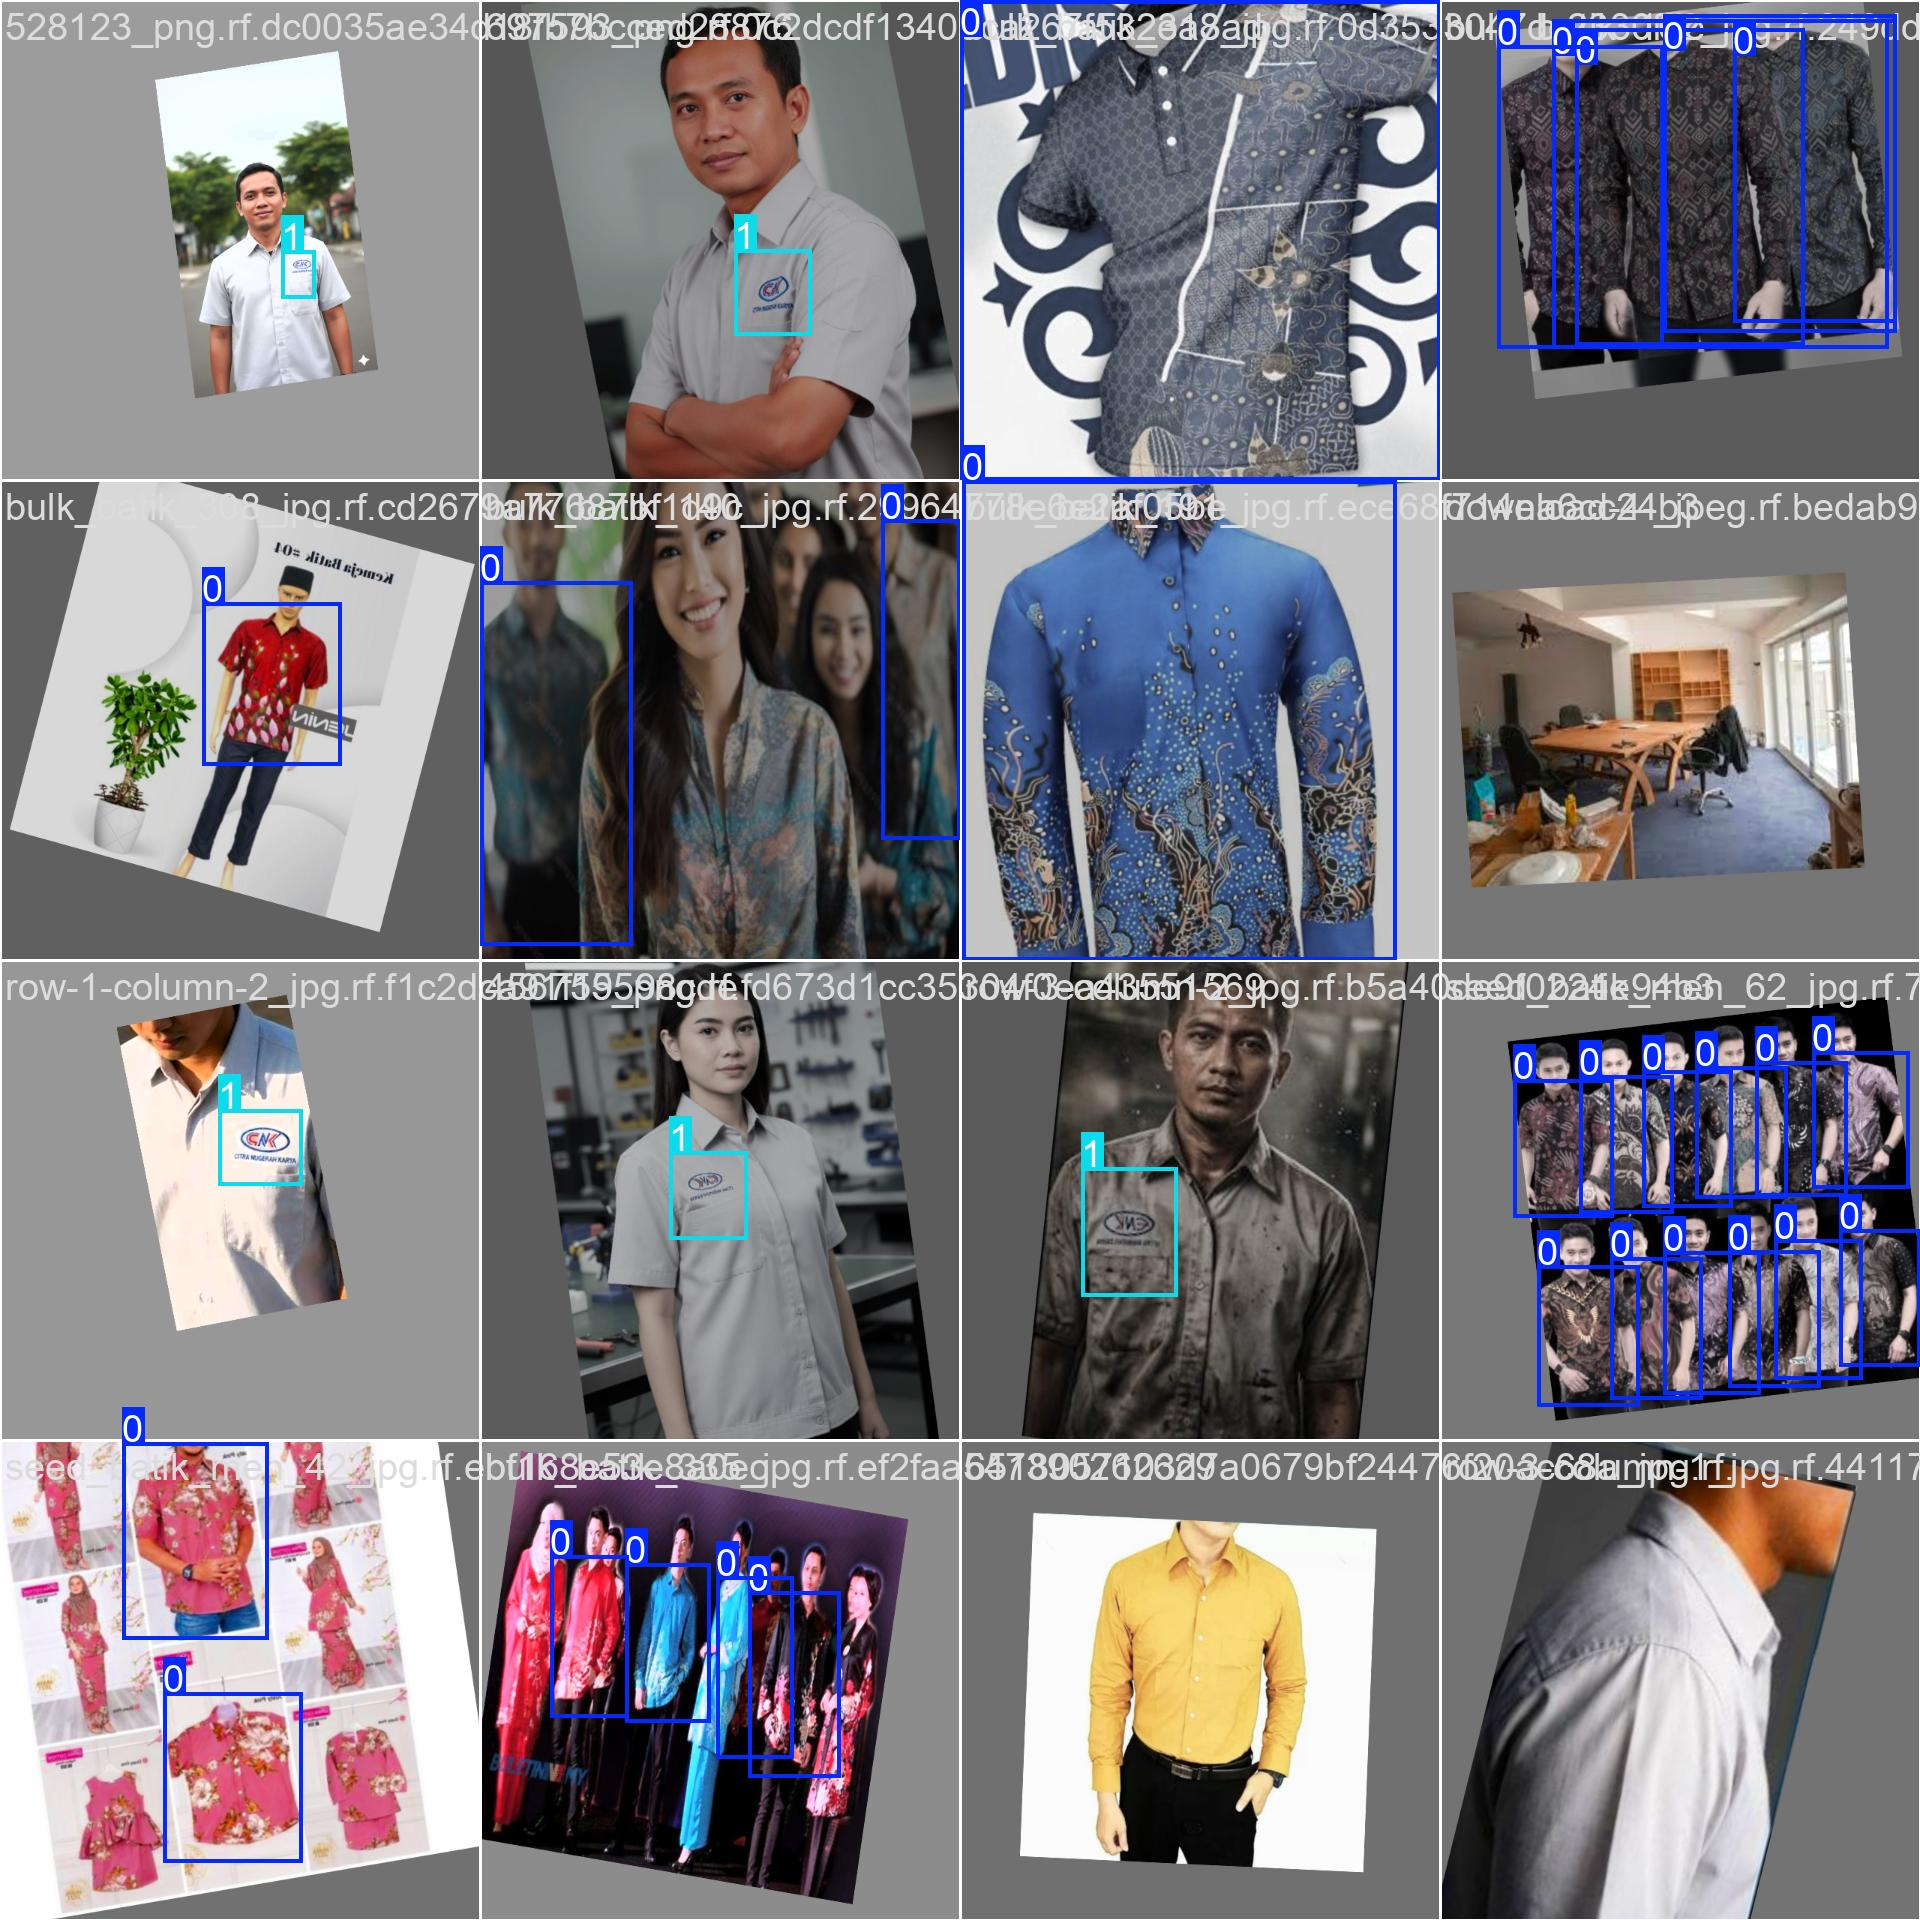

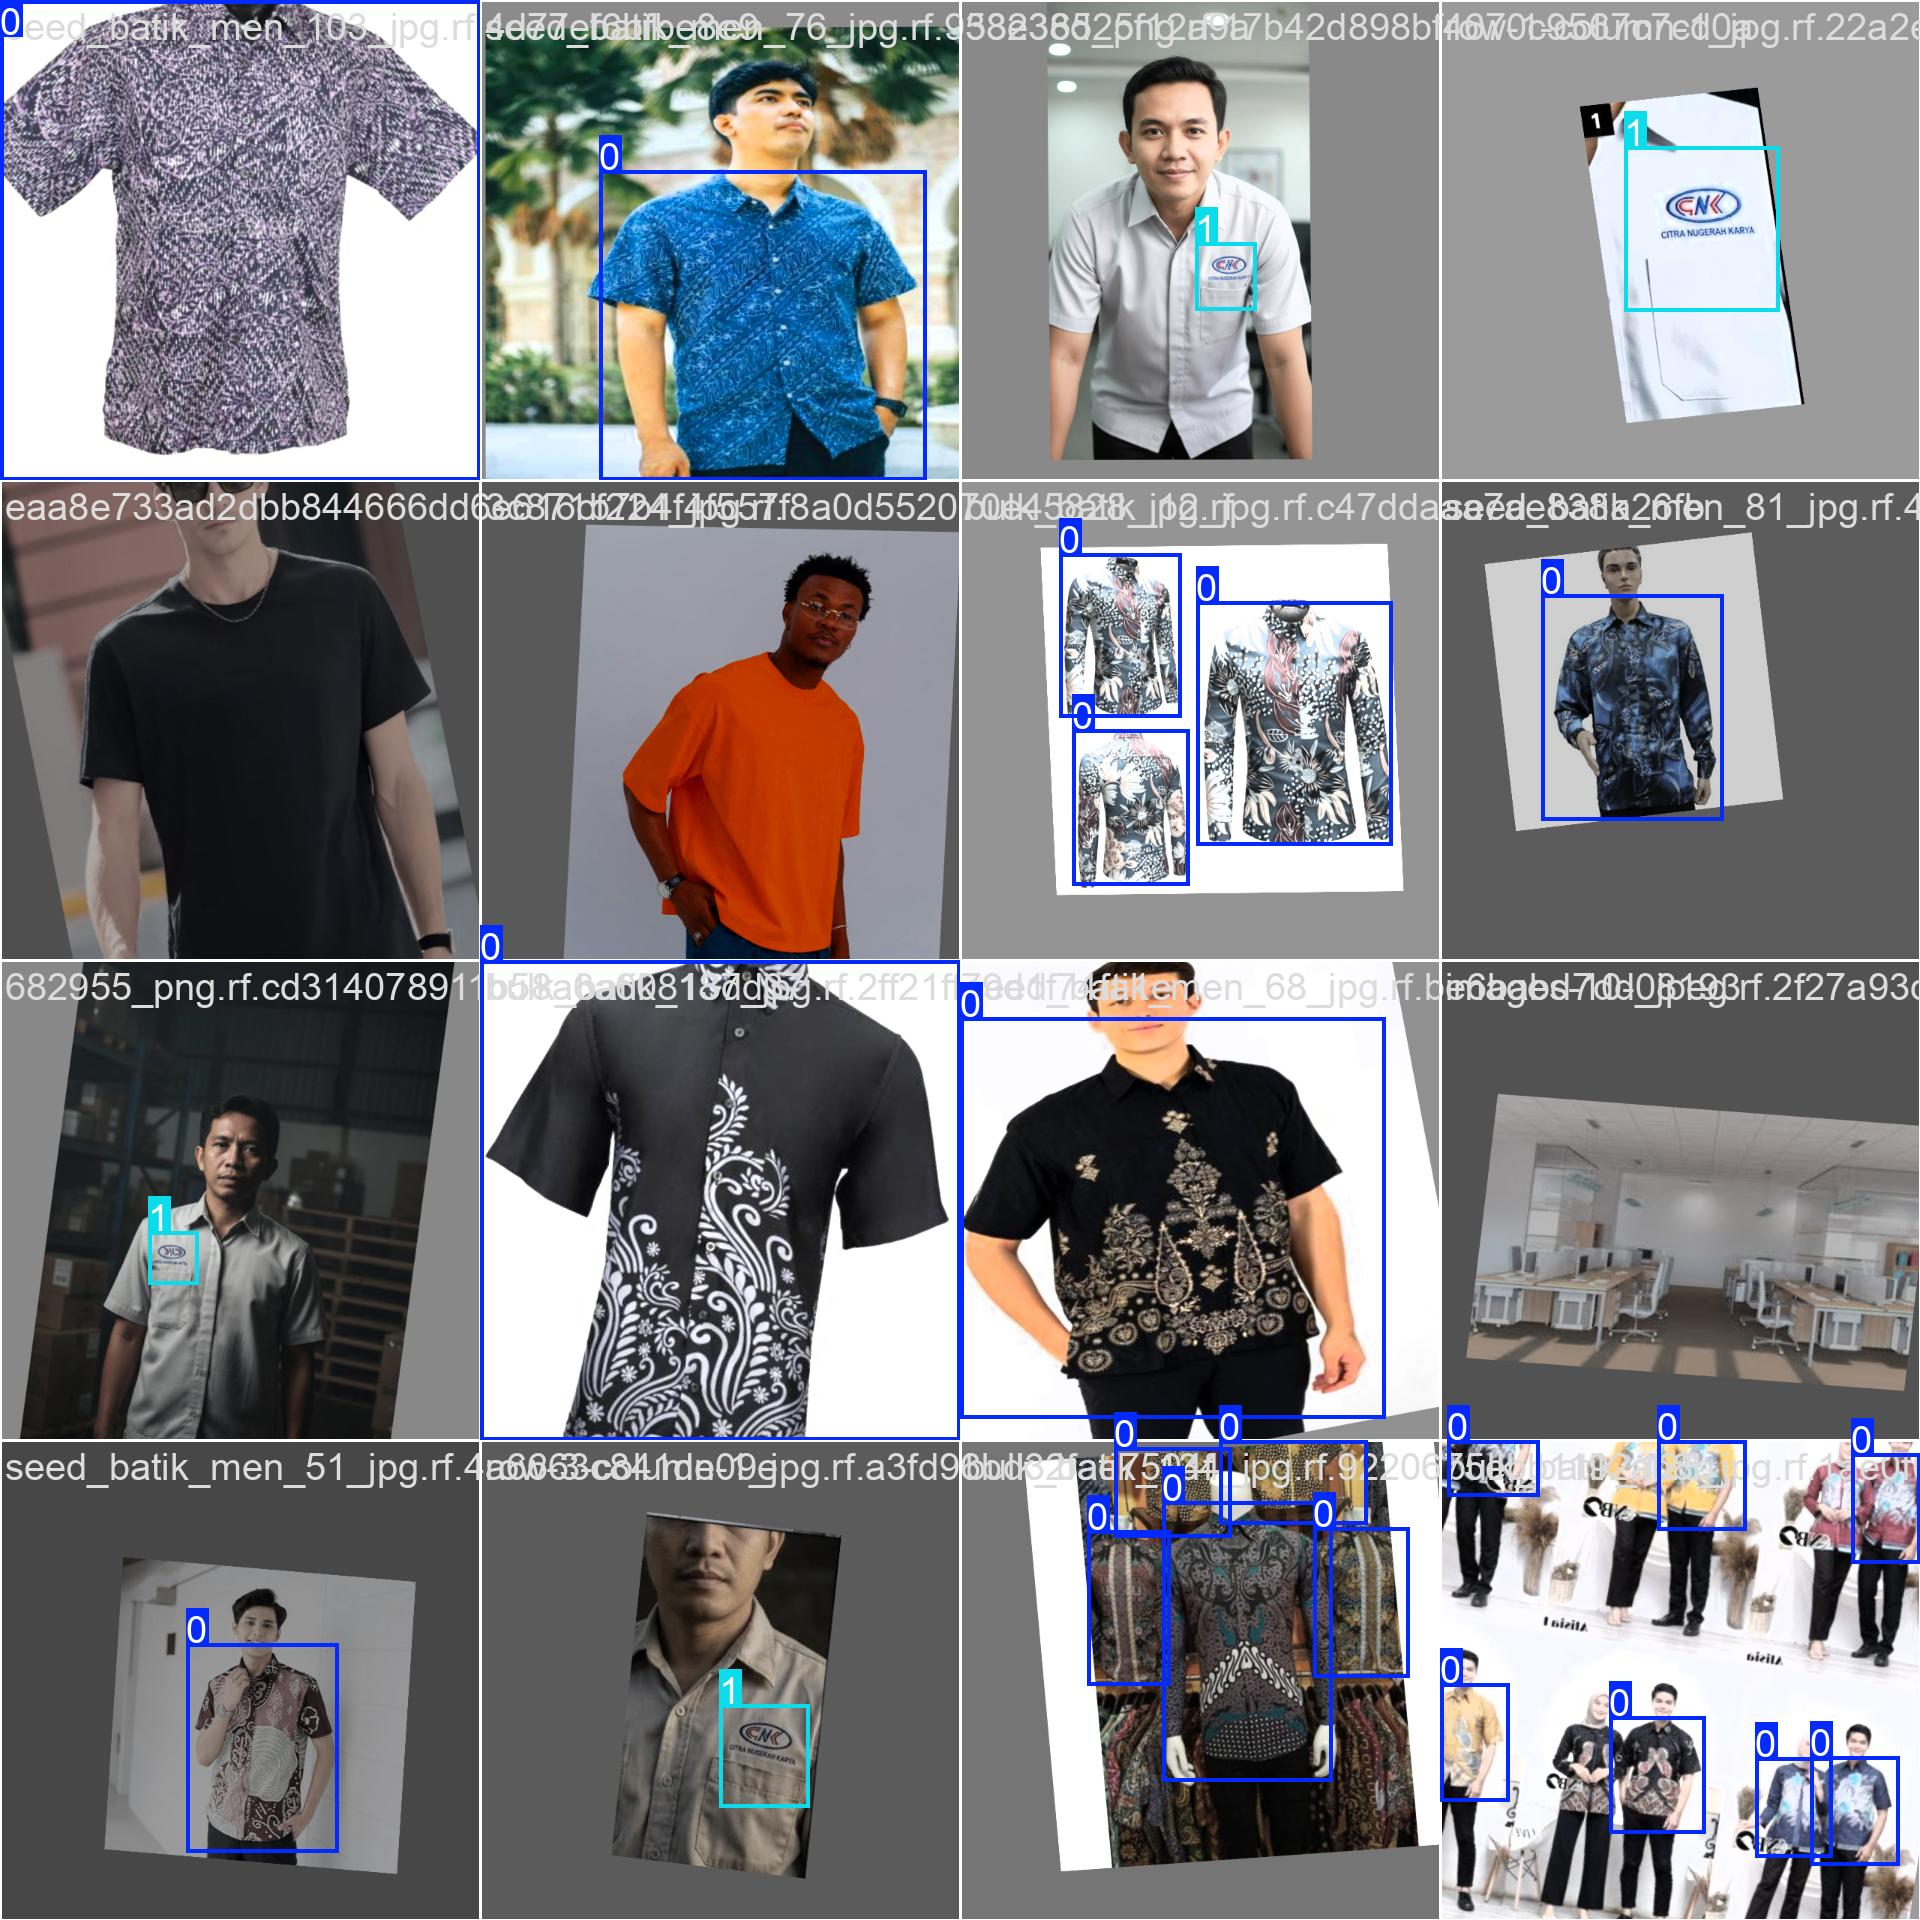

In [ ]:
import glob
from IPython.display import Image, display

# YOLO biasanya menyimpan hasilnya di folder runs/detect/train
batch_images = glob.glob('/content/runs/detect/train/train_batch*.jpg')

if len(batch_images) > 0:
    print("📸 Ini adalah hasil augmentasi (Mosaic, dll) yang sedang dicerna oleh YOLO:")
    # Menampilkan 2 gambar batch pertama
    for img_path in batch_images[:2]:
        display(Image(filename=img_path, width=800))
else:
    print("⏳ Gambar belum tersedia. Pastikan proses training sudah melewati Epoch 1!")


image 1/1 /content/WhatsApp Image 2026-03-25 at 3.34.56 PM.jpeg: 384x640 (no detections), 253.9ms
Speed: 2.9ms preprocess, 253.9ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)


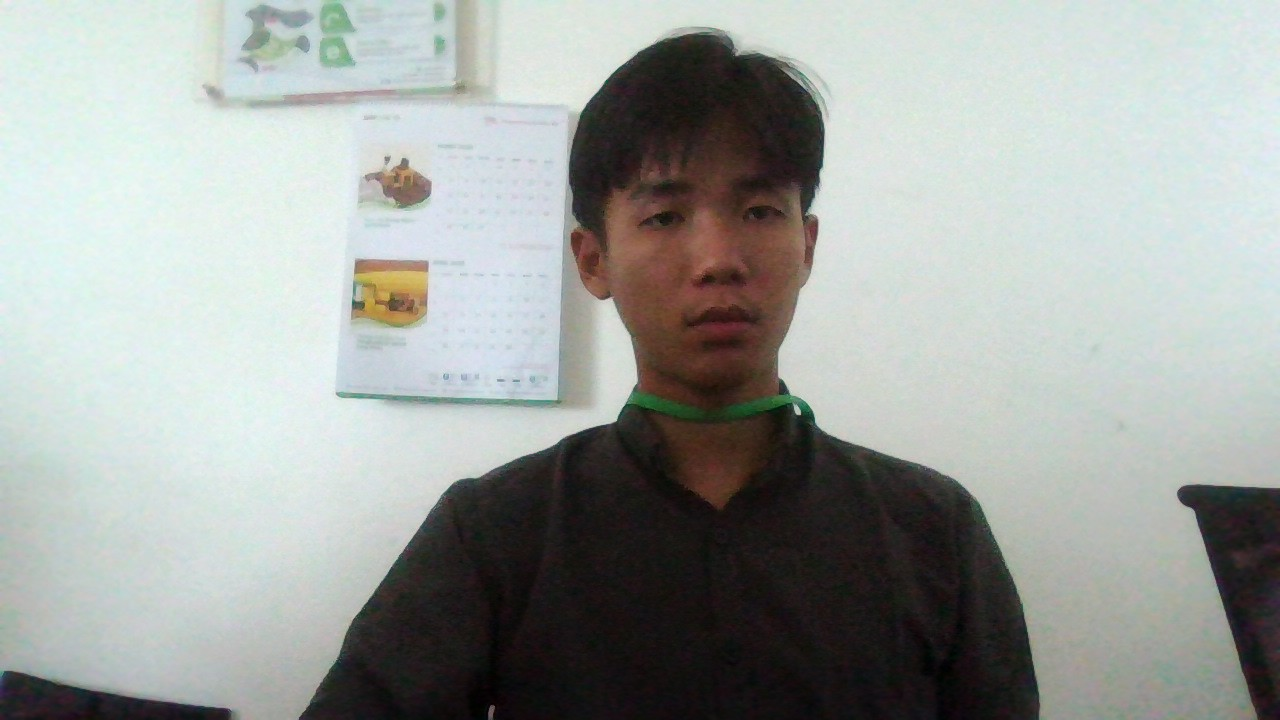

In [ ]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

# 1. Load model terbaik hasil training tadi
model = YOLO('/content/yolov8_cnk_best (3).pt')

# 2. Jalankan prediksi pada foto baru (Unggah foto test kamu ke folder Colab)
results = model.predict(source='/content/WhatsApp Image 2026-03-25 at 2.49.48 PM.jpeg', conf=0.65)

# 3. Tampilkan hasil
for r in results:
    im_array = r.plot()  # Menggambar bounding box di gambar
    cv2_imshow(im_array)

In [ ]:
import shutil
import os

# 1. Path asal model terbaik dari YOLO
# (Cek folder di sidebar kiri Colab jika namanya train2 atau train3)
sumber_model = '/content/runs/detect/train/weights/best.pt'

# 2. Path tujuan di Google Drive kamu
# Ganti dengan nama folder yang kamu inginkan
folder_tujuan = '/content/drive/MyDrive/Model_CNK_Project'
file_tujuan = os.path.join(folder_tujuan, 'yolov8_cnk_best.pt')

# 3. Eksekusi pemindahan
if os.path.exists(sumber_model):
    # Buat folder di Drive jika belum ada
    os.makedirs(folder_tujuan, exist_ok=True)

    # Copy file ke Drive
    shutil.copy(sumber_model, file_tujuan)
    print(f"✅ SUKSES! Model berhasil diamankan ke: {file_tujuan}")
else:
    print("❌ GAGAL! File best.pt tidak ditemukan. Cek kembali path foldernya.")

✅ SUKSES! Model berhasil diamankan ke: /content/drive/MyDrive/Model_CNK_Project/yolov8_cnk_best.pt


In [ ]:
metrics = model.val(split='test')
print(f"Akurasi mAP50 pada data TEST asli: {metrics.results_dict['metrics/mAP50(B)']}")